In [2]:
import torch
from d2l import torch as d2l

The goal of language models is to estimate the joint probability of the whole sequence / sentence. LM can be used to generate text. One way to model languages is to use k order Markov models

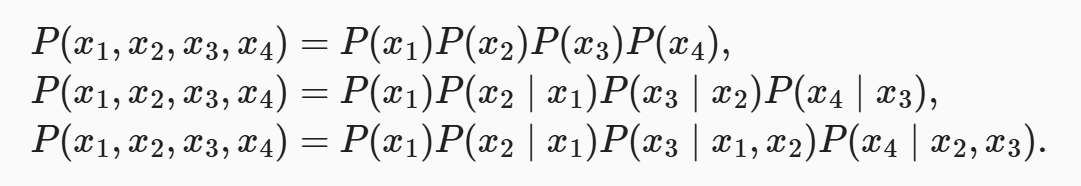

The probability formulae that involve one, two, and three variables are typically referred to as unigram, bigram, and trigram models, respectively. In order to compute the language model, we need to calculate the probability of words and the conditional probability of a word given the previous few words. 

**Note that such probabilities are language model parameters.**

In [ ]:
@d2l.add_to_class(d2l.TimeMachine) #@save
def __init__(self, batch_size, num_steps, num_train=10000, num_val=5000):
    super(d2l.TimeMachine, self).__init__()
    self.save_hyperparameters()
    corpus, self.vocab = self.build(self._download())
    array = torch.tensor(
        [corpus[i:i+num_stemps+1] for i in range(len(corpus)-num_steps)]
    )
    self.X, self.Y = array[:,:-1], array[:,1:]
    

In [4]:
@d2l.add_to_class(d2l.TimeMachine) #@save
def get_dataloader(self, train):
    idx = slice(0, self.num_train) if train else slice(self.num_train, self.num_train+self.num_val)
    return self.get_tensorloader([self.X, self.Y], train, idx)